# FINd — 5-minute integration tutorial

Walks through how to use the FINd image hashing library:

1. **Library mode** — import and call from Python
2. **Interpreting hashes** — what a 256-bit hash looks like and how to compare
3. **Near-duplicate detection** — find which images in a folder are the same meme
4. **Threshold selection** — picking the right Hamming distance cutoff
5. **API mode** — calling the FastAPI service from any HTTP client
6. **Batch hashing for large archives** — processing thousands of images efficiently

## 0. Setup

Install with `pip install -e ".[api,dev]"` (matplotlib needed for the heatmap). Requires the `meme_images/` dataset — see `README.md`.

In [1]:
import sys, os
from pathlib import Path

# Make project root importable when running notebook from notebooks/ subdir
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

IMG_DIR = PROJECT_ROOT / 'meme_images'
print(f'Project root: {PROJECT_ROOT.name}/')
print(f'Dataset present: {IMG_DIR.exists()} ({len(list(IMG_DIR.glob("*.jpg"))) if IMG_DIR.exists() else 0} images)')

Project root: summative2026/
Dataset present: True (55972 images)


## 1. Library mode — hash a single image

This is the simplest use: import the hasher, call `fromFile`, get back a hash object.

In [2]:
from find_image_hashing import FINDHasherOptimized

# Create the hasher once at startup — reusable for any number of images.
hasher = FINDHasherOptimized()

# Hash one image
sample_image = next(IMG_DIR.glob('*.jpg'))
print(f'Hashing: {sample_image.name}')

hash_obj = hasher.fromFile(str(sample_image))
print(f'\nHash object: {hash_obj}')
print(f'Type:        {type(hash_obj).__name__}')
print(f'Hex string:  {str(hash_obj)}')
print(f'Length:      {len(str(hash_obj))} characters ({len(str(hash_obj)) * 4} bits)')

Hashing: 0660_23034755.jpg

Hash object: 20f7881c9e863231efca8d383cf4c35fc69cd844b1e13a69be787c9a661d7382
Type:        ImageHash
Hex string:  20f7881c9e863231efca8d383cf4c35fc69cd844b1e13a69be787c9a661d7382
Length:      64 characters (256 bits)


## 2. Compare two images

Hashing one image isn't useful on its own — the value is comparing two. Subtract two hashes to get the **Hamming distance** (number of bit positions that differ, 0–256).

In [3]:
# Find two images from the same meme cluster (same prefix = same template)
images_in_cluster_0 = sorted(IMG_DIR.glob('0000_*.jpg'))[:2]
img_a, img_b = images_in_cluster_0
print(f'A: {img_a.name}')
print(f'B: {img_b.name}')

hash_a = hasher.fromFile(str(img_a))
hash_b = hasher.fromFile(str(img_b))

print(f'\nA hash: {hash_a}')
print(f'B hash: {hash_b}')

distance = hash_a - hash_b
print(f'\nHamming distance: {distance} bits out of 256')
print(f'Similarity:       {(256 - distance) / 256 * 100:.1f}% bits match')

A: 0000_12268686.jpg
B: 0000_12270286.jpg

A hash: 393b246d65a694dc5386279b8e7394f04c9da697877b18a31995ab9893235b65
B hash: 18ab6c6f4cae949c591e27998c3394f8588da4d7a74b18a332d6a3d89363db65

Hamming distance: 40 bits out of 256
Similarity:       84.4% bits match


**Interpretation of the distance**:

| distance range | meaning | use it when |
|---|---|---|
| 0 | bit-exact identical hashes | exact duplicate detection |
| 1–50 | very similar, almost certainly same content with minor edits | safe to auto-act (block, dedupe) |
| 50–90 | similar — likely related but might be re-cropped, recolored, edited | flag for human review |
| 90–130 | edge case — could go either way | uncertain, requires context |
| 130+ | unrelated images | filter out, treat as different |

Cutoffs come from ROC analysis on meme_images; the API returns them as `threshold_recommendation`.

## 3. Near-duplicate detection across a folder

Now the realistic use case: you have a folder of images, and you want to find which ones are duplicates / near-duplicates of each other.

We sample 20 images from 4 different meme clusters (so 5 from each), hash all of them, and check pairwise distances.

In [4]:
import random
random.seed(42)

# Pick 4 random clusters with at least 5 images each
clusters = {}
for f in IMG_DIR.iterdir():
    if f.suffix == '.jpg':
        cluster_id = f.name.split('_')[0]
        clusters.setdefault(cluster_id, []).append(f)

big_clusters = [cid for cid, files in clusters.items() if len(files) >= 5]
chosen = random.sample(big_clusters, 4)
sample_files = []
for cid in chosen:
    sample_files.extend(random.sample(clusters[cid], 5))

print(f'Sampled {len(sample_files)} files from clusters: {chosen}')
print(f'\nFirst few files:')
for f in sample_files[:6]:
    print(f'  {f.name}')

Sampled 20 files from clusters: ['0482', '0432', '0151', '0838']

First few files:
  0482_17892630.jpg
  0482_16950503.jpg
  0482_16950443.jpg
  0482_11959227.jpg
  0482_16729773.jpg
  0432_11126228.jpg


In [5]:
# Hash all 20 files (~100 ms total at 5 ms each)
import time

t0 = time.perf_counter()
hashes = {f.name: hasher.fromFile(str(f)) for f in sample_files}
elapsed_ms = (time.perf_counter() - t0) * 1000

print(f'Hashed {len(hashes)} images in {elapsed_ms:.0f} ms ({elapsed_ms/len(hashes):.1f} ms/img)')

Hashed 20 images in 111 ms (5.6 ms/img)


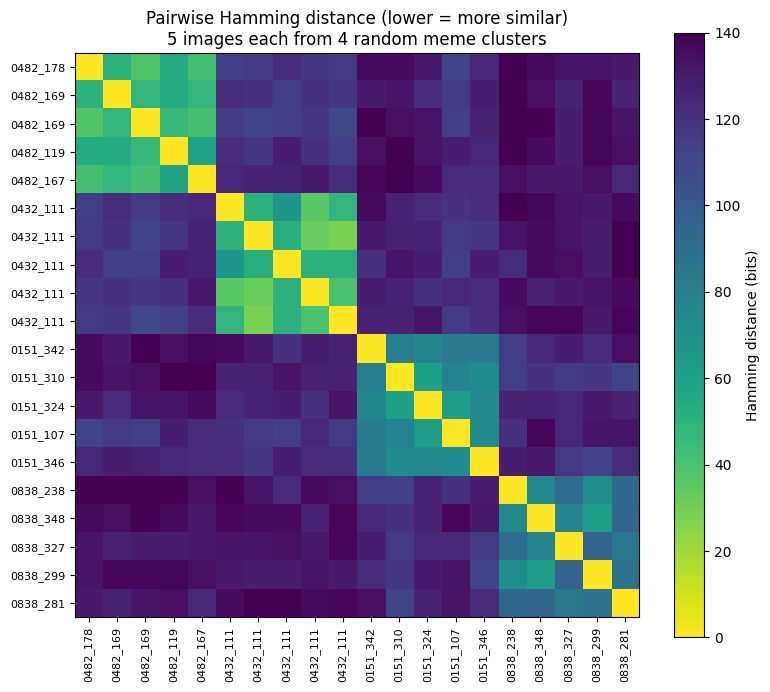

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Build pairwise distance matrix
names = list(hashes.keys())
n = len(names)
distances = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        distances[i, j] = hashes[names[i]] - hashes[names[j]]

# Heatmap: same-cluster pairs form dark blocks on the diagonal
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(distances, cmap='viridis_r', vmin=0, vmax=140)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([nm[:8] for nm in names], rotation=90, fontsize=8)
ax.set_yticklabels([nm[:8] for nm in names], fontsize=8)
ax.set_title('Pairwise Hamming distance (lower = more similar)\n5 images each from 4 random meme clusters')
plt.colorbar(im, ax=ax, label='Hamming distance (bits)')
plt.tight_layout()
plt.show()

**Reading the heatmap**: dark squares (low distance) = pairs the algorithm thinks are very similar. The 4 dark 5×5 blocks along the diagonal correspond to the 4 clusters — within-cluster images are correctly identified as similar. The brighter background = pairs from different clusters, correctly identified as different.

## 4. Threshold selection — filter pairs by use case

Once you have a hash database, you usually want to **find duplicates above some similarity threshold**. The right threshold depends on your use case:

In [7]:
def find_duplicates(hash_dict, threshold):
    """Return all (file_a, file_b, distance) triples where distance <= threshold."""
    pairs = []
    names = list(hash_dict.keys())
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            d = hash_dict[names[i]] - hash_dict[names[j]]
            if d <= threshold:
                pairs.append((names[i], names[j], d))
    return sorted(pairs, key=lambda x: x[2])

# 'high precision' = strict, only flags very-confident duplicates
strict = find_duplicates(hashes, threshold=50)
print(f'High-precision (threshold=50): {len(strict)} pairs flagged')
for a, b, d in strict[:5]:
    print(f'  {d:3d} bits — {a[:14]} ↔ {b[:14]}')

# 'balanced' = moderate, FPR ~1%
balanced = find_duplicates(hashes, threshold=90)
print(f'\nBalanced (threshold=90): {len(balanced)} pairs flagged')

# 'high recall' = lenient, catches more borderline cases
lenient = find_duplicates(hashes, threshold=130)
print(f'High-recall (threshold=130): {len(lenient)} pairs flagged')

High-precision (threshold=50): 15 pairs flagged
   28 bits — 0432_11126114. ↔ 0432_11125235.
   32 bits — 0432_11126114. ↔ 0432_11139737.
   36 bits — 0432_11126228. ↔ 0432_11139737.
   38 bits — 0482_17892630. ↔ 0482_16950443.
   40 bits — 0432_11139737. ↔ 0432_11125235.

Balanced (threshold=90): 37 pairs flagged
High-recall (threshold=130): 136 pairs flagged


## 5. API mode — call the running FastAPI service

If your application isn't Python, or if you want to deploy FINd as a microservice, use the HTTP API. Start the server first:

```bash
docker run -d --rm -p 8945:8945 fin/find
# or
python -m api
```

Then call it from any HTTP client. Below we use Python's `httpx` for illustration.

In [8]:
# This cell ASSUMES the API is running on http://127.0.0.1:8945
# If you haven't started it, this will time out — that's expected.
import httpx

API_URL = 'http://127.0.0.1:8945'

# Probe /health first to confirm the server is up
try:
    r = httpx.get(f'{API_URL}/health', timeout=2.0)
    print(f'Server status: {r.json()}')
    server_up = True
except Exception as e:
    print(f'Server not reachable: {e}')
    print('Start it with: docker run -d --rm -p 8945:8945 fin/find')
    server_up = False

Server not reachable: [Errno 61] Connection refused
Start it with: docker run -d --rm -p 8945:8945 fin/find


In [9]:
# If server is up, call /compare
if server_up:
    with open(sample_files[0], 'rb') as f1, open(sample_files[1], 'rb') as f2:
        files = {
            'image1': (sample_files[0].name, f1.read(), 'image/jpeg'),
            'image2': (sample_files[1].name, f2.read(), 'image/jpeg'),
        }
    r = httpx.post(f'{API_URL}/compare', files=files, timeout=10.0)
    response = r.json()
    print(f'HTTP {r.status_code}')
    for key, val in response.items():
        print(f'  {key}: {val}')
else:
    print('(skipped — start the server to run this cell)')

(skipped — start the server to run this cell)


**API response fields**:

- `image1_hash`, `image2_hash`, `distance` — assignment-brief contract; byte-for-byte identical to library output
- `confidence` — interpreted bucket label (high / medium / low)
- `image{1,2}_meta` — width / height / size_bytes for downstream pipelines
- `threshold_recommendation` — calibrated cutoffs (consumer can override)

Visit `http://127.0.0.1:8945/docs` for the auto-generated Swagger UI.

## 6. Batch hashing for large archives

If you have thousands of images to hash (e.g. building an initial database), don't loop over them with the API, just call the library directly. Each hash takes ~5 ms; 10,000 images = ~50 seconds single-threaded.

In [10]:
# Demo: hash 100 images sequentially, print throughput
batch_files = list(IMG_DIR.glob('*.jpg'))[:100]

t0 = time.perf_counter()
batch_hashes = {f.name: hasher.fromFile(str(f)) for f in batch_files}
elapsed_s = time.perf_counter() - t0

print(f'Hashed {len(batch_files)} images in {elapsed_s:.2f} s')
print(f'Mean per image: {elapsed_s / len(batch_files) * 1000:.1f} ms')
print(f'Throughput:     {len(batch_files) / elapsed_s:.0f} images/sec')
print()
print(f'Projected for full meme_images dataset (55 972 imgs):')
print(f'  Single-threaded: {55972 * elapsed_s / len(batch_files) / 60:.1f} minutes')
print(f'  With 4 workers (multiprocessing.Pool): ~{55972 * elapsed_s / len(batch_files) / 60 / 4:.1f} minutes')

Hashed 100 images in 0.53 s
Mean per image: 5.3 ms
Throughput:     187 images/sec

Projected for full meme_images dataset (55 972 imgs):
  Single-threaded: 5.0 minutes
  With 4 workers (multiprocessing.Pool): ~1.2 minutes


## You're done!

Issues / deployment questions: see `README.md` → **Get in touch with FIN**.